### The following cells are modified from Ilya's Code to fit into our project

Category: Appliances

In [19]:
import os
import duckdb
import pandas as pd
from tqdm import tqdm
from pathlib import Path

In [20]:
RAW_DATA_DIR = Path("../data/raw")
PROCESSED_DATA_DIR = Path("../data/processed")
CATEGORY = "Appliances"
BASE_URL = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw"
REVIEWS_URL = f"{BASE_URL}/review_categories/{CATEGORY}.jsonl.gz"
META_URL    = f"{BASE_URL}/meta_categories/meta_{CATEGORY}.jsonl.gz"
REVIEWS_FILE = RAW_DATA_DIR / f"{CATEGORY}.jsonl.gz"
META_FILE    = RAW_DATA_DIR / f"meta_{CATEGORY}.jsonl.gz"
OUTPUT_FILE  = RAW_DATA_DIR / f"{CATEGORY}_merged.parquet"

In [21]:
print(os.listdir())
print(RAW_DATA_DIR)
print(REVIEWS_URL)

['milestone1_exploration.ipynb', 'demo.ipynb', 'project_eda_duckdb.ipynb', 'milestone1_exploration_harrison.ipynb']
../data/raw
https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/Appliances.jsonl.gz


### Initialize an in-memory DB connection

In [22]:
c2 = duckdb.connect()

Review data:
- keep `rating, title, text, parent_asin, helpful_vote` columns only while downloading data
- other columns seems useless

In [23]:
c2.execute(f"SELECT * FROM read_json_auto('{REVIEWS_URL}') LIMIT 5").df()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Work great,work great. use a new one every month,[],B01N0TQ0OH,B01N0TQ0OH,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1519317108692,0,True
1,5.0,excellent product,Little on the thin side,[],B07DD2DMXB,B07DD37QPZ,AHWWLSPCJMALVHDDVSUGICL6RUCA,1664746863446,0,True
2,5.0,Happy customer!,"Quick delivery, fixed the issue!",[],B082W3Z9YK,B082W3Z9YK,AHZIJGKEWRTAEOZ673G5B3SNXEGQ,1607225435363,0,True
3,5.0,Amazing value,I wasn't sure whether these were worth it or n...,[],B078W2BJY8,B078W2BJY8,AFGUPTDFAWOHHL4LZDV27ERDNOYQ,1534104184306,0,True
4,5.0,Dryer parts,Easy to install got the product expected to re...,[],B08C9LPCQV,B08C9LPCQV,AELFJFAXQERUSMTXJQ6SYFFRDWMA,1620176603754,0,True


Meta data
- Drop images and videos while downloading data since we can't process it through links.
- other columns seems useful

In [24]:
c2.execute(f"SELECT * FROM read_json_auto('{META_URL}') LIMIT 5").df()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,Industrial & Scientific,"ROVSUN Ice Maker Machine Countertop, Make 44lb...",3.7,61,[【Quick Ice Making】This countertop ice machine...,[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Our Point of View on the Euhomy Ic...,ROVSUN,"[Appliances, Refrigerators, Freezers & Ice Mak...","{'Brand': '""ROVSUN""', 'Model Name': '""ICM-2005...",B08Z743RRD,None
1,Tools & Home Improvement,"HANSGO Egg Holder for Refrigerator, Deviled Eg...",4.2,75,"[Plastic, Practical Kitchen Storage - Our egg ...",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': '10 Eggs Egg Holder for Refrigerato...,HANSGO,"[Appliances, Parts & Accessories, Refrigerator...","{'Manufacturer': '""HANSGO""', 'Part Number': '""...",B097BQDGHJ,None
2,Tools & Home Improvement,"Clothes Dryer Drum Slide, General Electric, Ho...",3.5,18,[],"[Brand new dryer drum slide, replaces General ...",NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],GE,"[Appliances, Parts & Accessories]","{'Manufacturer': '""RPI""', 'Part Number': '""WE1...",B00IN9AGAE,None
3,Tools & Home Improvement,154567702 Dishwasher Lower Wash Arm Assembly f...,4.5,26,[MODEL NUMBER:154567702 Dishwasher Lower Wash ...,[MODEL NUMBER:154567702 Dishwasher Lower Wash ...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],folosem,"[Appliances, Parts & Accessories, Dryer Parts ...","{'Manufacturer': '""folosem""', 'Part Number': '...",B0C7K98JZS,None
4,Tools & Home Improvement,Whirlpool W10918546 Igniter,3.8,12,[This is a Genuine OEM Replacement Part.],[Whirlpool Igniter],25.07,[{'thumb': 'https://m.media-amazon.com/images/...,[],Whirlpool,"[Appliances, Parts & Accessories]","{'Manufacturer': '""Whirlpool""', 'Part Number':...",B07QZHQTVJ,None


### download data in parquet if it doesn't exist in the directory

In [25]:
review_data_file = f'{CATEGORY}_reviews_raw.parquet'
meta_data_file = f'{CATEGORY}_meta_raw.parquet'

if review_data_file not in os.listdir(RAW_DATA_DIR):
    print("Downloading Review Data\nCategory: {}".format(CATEGORY))
    c2.execute(f"""
          COPY (SELECT rating, title, text, parent_asin, helpful_vote FROM read_json_auto('{REVIEWS_URL}'))
          TO '{RAW_DATA_DIR}/{review_data_file}'
          (FORMAT PARQUET, COMPRESSION ZSTD)
      """)
    print("Done")
else:
    print("Review data for {} already downloaded".format(CATEGORY))

Review data for Appliances already downloaded


In [26]:
c2.execute(f"SELECT * FROM read_parquet('{RAW_DATA_DIR}/{review_data_file}') LIMIT 5").df()

,rating,title,text,parent_asin,helpful_vote
0,5.0,Work great,work great. use a new one every month,B01N0TQ0OH,0
1,5.0,excellent product,Little on the thin side,B07DD37QPZ,0
2,5.0,Happy customer!,"Quick delivery, fixed the issue!",B082W3Z9YK,0
3,5.0,Amazing value,I wasn't sure whether these were worth it or n...,B078W2BJY8,0
4,5.0,Dryer parts,Easy to install got the product expected to re...,B08C9LPCQV,0


In [27]:
if meta_data_file not in os.listdir(RAW_DATA_DIR):
    print("Downloading Meta Data\nCategory: {}".format(CATEGORY))
    c2.execute(f"""
    COPY (SELECT * EXCLUDE (images, videos) FROM read_json_auto('{META_URL}', union_by_name=true))
    TO '{RAW_DATA_DIR}/{meta_data_file}'
    (FORMAT PARQUET, COMPRESSION ZSTD)
    """)
    print("Done")
else:
    print("Meta data for {} already downloaded".format(CATEGORY))


Meta data for Appliances already downloaded


In [28]:
c2.execute(f"SELECT * FROM read_parquet('{RAW_DATA_DIR}/{meta_data_file}') LIMIT 5").df()

,main_category,title,average_rating,rating_number,features,description,price,store,categories,details,parent_asin,bought_together
0,Industrial & Scientific,"ROVSUN Ice Maker Machine Countertop, Make 44lb...",3.7,61,[【Quick Ice Making】This countertop ice machine...,[],NaN,ROVSUN,"[Appliances, Refrigerators, Freezers & Ice Mak...","{'Brand': '""ROVSUN""', 'Model Name': '""ICM-2005...",B08Z743RRD,None
1,Tools & Home Improvement,"HANSGO Egg Holder for Refrigerator, Deviled Eg...",4.2,75,"[Plastic, Practical Kitchen Storage - Our egg ...",[],NaN,HANSGO,"[Appliances, Parts & Accessories, Refrigerator...","{'Manufacturer': '""HANSGO""', 'Part Number': '""...",B097BQDGHJ,None
2,Tools & Home Improvement,"Clothes Dryer Drum Slide, General Electric, Ho...",3.5,18,[],"[Brand new dryer drum slide, replaces General ...",NaN,GE,"[Appliances, Parts & Accessories]","{'Manufacturer': '""RPI""', 'Part Number': '""WE1...",B00IN9AGAE,None
3,Tools & Home Improvement,154567702 Dishwasher Lower Wash Arm Assembly f...,4.5,26,[MODEL NUMBER:154567702 Dishwasher Lower Wash ...,[MODEL NUMBER:154567702 Dishwasher Lower Wash ...,NaN,folosem,"[Appliances, Parts & Accessories, Dryer Parts ...","{'Manufacturer': '""folosem""', 'Part Number': '...",B0C7K98JZS,None
4,Tools & Home Improvement,Whirlpool W10918546 Igniter,3.8,12,[This is a Genuine OEM Replacement Part.],[Whirlpool Igniter],25.07,Whirlpool,"[Appliances, Parts & Accessories]","{'Manufacturer': '""Whirlpool""', 'Part Number':...",B07QZHQTVJ,None


### Merging the two files by joining on `parent_asin`

In [29]:
merged_data_file = f'{CATEGORY}_merged.parquet'

if merged_data_file not in os.listdir(PROCESSED_DATA_DIR):
    print("Merging Review/Meta Data\nCategory: {}".format(CATEGORY))
    c2.execute(f"""
        COPY (
            SELECT r.*, m.title AS product_title, m.price,
                        m.average_rating, m.main_category, m.store
            FROM read_parquet('{RAW_DATA_DIR}/{review_data_file}') r
            LEFT JOIN read_parquet('{RAW_DATA_DIR}/{meta_data_file}') m USING (parent_asin)
        )
        TO '{PROCESSED_DATA_DIR}/{merged_data_file}' (FORMAT PARQUET, COMPRESSION ZSTD)
    """)
    print("Done")
else:
    print("Merged data for {} is ready".format(CATEGORY))

Merged data for Appliances is ready


In [30]:
merged_data = c2.execute(f"SELECT * FROM read_parquet('{PROCESSED_DATA_DIR}/{merged_data_file}')").df()
merged_data

,rating,title,text,parent_asin,helpful_vote,product_title,price,average_rating,main_category,store
0,5.0,Exactly what we needed at a great price,Initially was gonna spend 65.00 on a new one f...,B001DHLGOS,1,Dryer Heating Element 279838 For Whirlpool/Ken...,29.03,4.5,Appliances,Napco
1,5.0,Good device,"Accurate, easy to use for work.",B0B4546WMS,4,"Protmex Digital Temperature Humidity Meter, Th...",54.99,4.6,Industrial & Scientific,Protmex
2,5.0,Five Stars,Great product,B01J0I0TQM,0,Mist DA29-00020B Water Filter Replacement. Com...,13.99,4.7,Appliances,Mist
3,5.0,Easier to clean,Excellent product,B0B2W8DNJ6,0,Fill 'n Brew Reusable Coffee Filter Basket for...,6.99,4.3,Amazon Home,Fill 'n Brew
4,5.0,Thank you!,Great value and fast delivery. Thank you.,B0C5PR3NWJ,0,Waterdrop MWF Water Filter for GE® Refrigerato...,33.29,4.7,Tools & Home Improvement,WATERDROP
...,...,...,...,...,...,...,...,...,...,...
2128600,5.0,Works as advertised,I live in a camper and my water is well water ...,B089ZRYXHN,0,COSTWAY 2-in-1 Water Cooler Dispenser with Bui...,NaN,3.8,Amazon Home,COSTWAY
2128601,1.0,Bad investment,Ice maker part stopped working in less than 1 ...,B07FNK4CBS,0,COSTWAY 2-in-1 Water Cooler Dispenser with Bui...,NaN,3.8,Amazon Home,COSTWAY
2128602,1.0,Bad investment,Ice maker part stopped working in less than 1 ...,B07FNK4CBS,0,COSTWAY 2-in-1 Water Cooler Dispenser with Bui...,NaN,3.8,Amazon Home,COSTWAY
2128603,1.0,Bad investment,Ice maker part stopped working in less than 1 ...,B07FNK4CBS,0,COSTWAY 2-in-1 Water Cooler Dispenser with Bui...,NaN,3.8,Amazon Home,COSTWAY


### EDA

#### Unique Product Count

In [31]:
c2.execute(f"""
    SELECT 
        COUNT(DISTINCT parent_asin) AS 'Number of Unique Products' 
    FROM 
        read_parquet('{PROCESSED_DATA_DIR}/{merged_data_file}')
""").df()

,Number of Unique Products
0,94319


#### Number of reviews for each product

In [32]:
review_counts = c2.execute(f"""
    SELECT 
        parent_asin,
        COUNT(*) AS review_count
    FROM read_parquet('{PROCESSED_DATA_DIR}/{merged_data_file}')
    GROUP BY parent_asin
    ORDER BY review_count DESC
""").df()
review_counts

,parent_asin,review_count
0,B0B3DB5HTC,12027
1,B07RNJY499,11620
2,B07WTXWC32,8519
3,B08YBGCNHP,7330
4,B000AST3AK,7030
...,...,...
94314,B00YD32MII,1
94315,B07YLCGRPV,1
94316,B08NK1Z94G,1
94317,B00J0F5NX0,1


#### Distribution of Review Counts

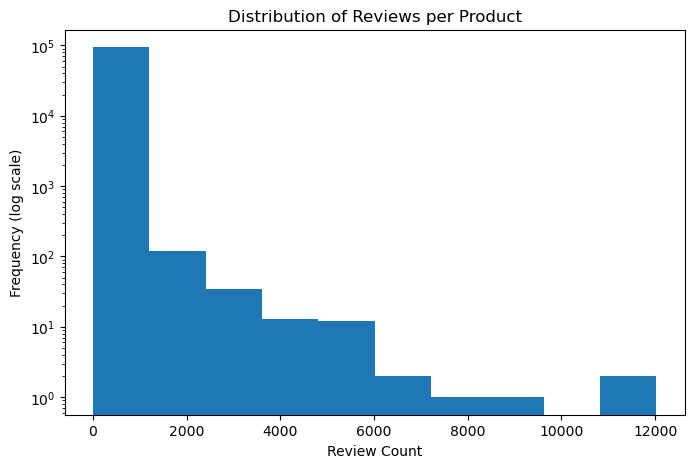

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
# sns.histplot(df_counts["review_count"], bins=50, log_scale=True)
plt.hist(review_counts["review_count"])
plt.title("Distribution of Reviews per Product")
plt.xlabel("Review Count")
plt.yscale('log')
plt.ylabel("Frequency (log scale)")
plt.show()

#### Distribution of Length of Reviews

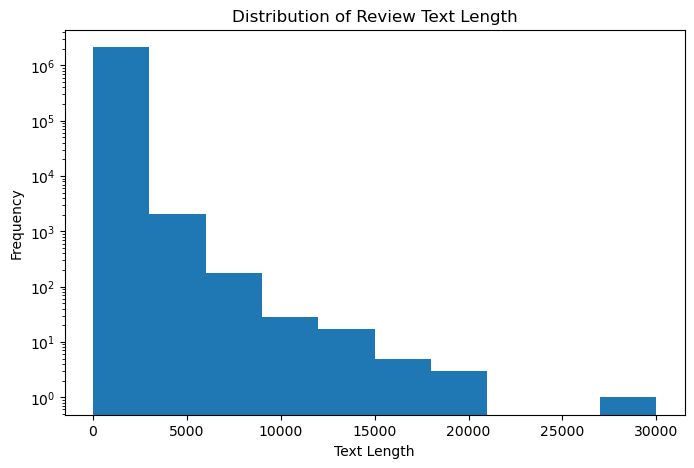

,text_len
0,0
1,0
2,0
3,0
4,0
...,...
2128600,16627
2128601,18632
2128602,19371
2128603,19401


In [34]:
text_length = c2.execute(f"""
    SELECT LENGTH(text) AS text_len
    FROM read_parquet('{PROCESSED_DATA_DIR}/{merged_data_file}')
    WHERE text IS NOT NULL
    ORDER BY text_len
""").df()

plt.figure(figsize=(8, 5))
plt.hist(text_length["text_len"])
plt.title("Distribution of Review Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.yscale("log")
plt.show()
text_length

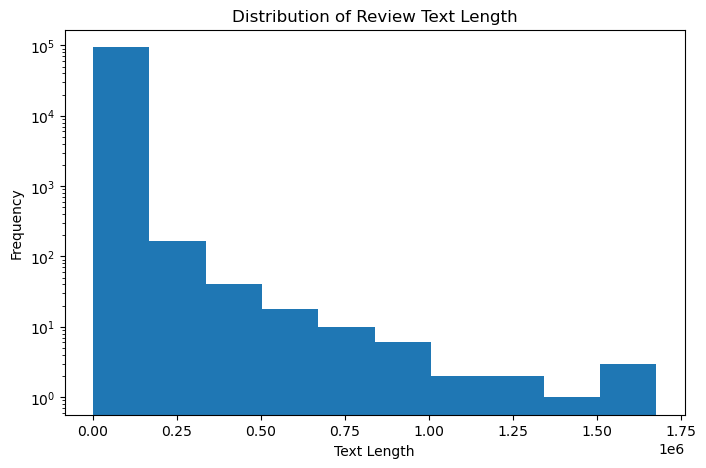

,parent_asin,total_text_size
0,B07RNJY499,1678364.0
1,B01ALBMIEI,1644603.0
2,B09YC8YCV6,1615904.0
3,B07YF9SGBW,1434920.0
4,B000DLB2FI,1314090.0
...,...,...
94314,B00ENL3DF6,1.0
94315,B09JVW6VBZ,1.0
94316,B00M9VDNJI,1.0
94317,B0BD53HLVM,1.0


In [35]:
total_text_length = c2.execute(f"""
    SELECT 
        parent_asin,
        SUM(LENGTH(text)) AS total_text_size
    FROM read_parquet('{PROCESSED_DATA_DIR}/{merged_data_file}')
    GROUP BY parent_asin
    ORDER BY total_text_size DESC
""").df()

plt.figure(figsize=(8, 5))
plt.hist(total_text_length["total_text_size"])
plt.title("Distribution of Review Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.yscale("log")
plt.show()
total_text_length

#### Duplicate Reviews

In [36]:
c2.execute(f"""
    SELECT 
        text,
        COUNT(*) as cnt
    FROM read_parquet('{PROCESSED_DATA_DIR}/{merged_data_file}')
    GROUP BY text
    HAVING cnt > 1
    ORDER BY cnt DESC
""").df()

,text,cnt
0,Works great,5244
1,Good,4678
2,Easy to install,4672
3,Great,4318
4,Perfect,3622
...,...,...
47276,Just the one I needed.,2
47277,I keep buying them,2
47278,"No issues, installed easily",2
47279,Fast delivery. Product as described. Thank you.,2


#### Missing Values

In [37]:
c2.execute(f"""
    SELECT
        COUNT(*) FILTER (WHERE product_title IS NULL) AS missing_product_title,
        COUNT(*) FILTER (WHERE text IS NULL) AS missing_text,
        COUNT(*) FILTER (WHERE main_category IS NULL) AS missing_category,
        COUNT(*) FILTER (WHERE store IS NULL) AS missing_store,
        COUNT(*) FILTER (WHERE price IS NULL) AS missing_price
    FROM read_parquet('{PROCESSED_DATA_DIR}/{merged_data_file}')
""").df()

,missing_product_title,missing_text,missing_category,missing_store,missing_price
0,0,0,28494,6064,528346


### Build Document for each product

In [38]:
print(merged_data.columns)

Index(['rating', 'title', 'text', 'parent_asin', 'helpful_vote',
       'product_title', 'price', 'average_rating', 'main_category', 'store'],
      dtype='str')


#### Group reviews by products

In [45]:
products_file = f'{CATEGORY}_products.parquet'

if products_file not in os.listdir(PROCESSED_DATA_DIR):
    print("Saving Products file\nCategory: {}".format(CATEGORY))
    c2.execute(f"""
        COPY (
            SELECT 
                parent_asin,
                ANY_VALUE(product_title) AS product_title,
                ANY_VALUE(main_category) AS main_category,
                ANY_VALUE(store) AS store,
                ANY_VALUE(price) AS price,
                ANY_VALUE(average_rating) AS avg_rating,
                LIST(text) AS reviews,
                LIST(title) AS review_titles,
                LIST(helpful_vote) AS helpful_votes
            FROM read_parquet('{PROCESSED_DATA_DIR}/{merged_data_file}')
            GROUP BY parent_asin
        )
        TO '{PROCESSED_DATA_DIR}/{products_file}' (FORMAT PARQUET, COMPRESSION ZSTD)
    """)
    print("Done")
else:
    print("Products Data for {} is ready".format(CATEGORY))

products = c2.execute(f"SELECT * FROM read_parquet('{PROCESSED_DATA_DIR}/{products_file}')").df()
products

Saving Products file
Category: Appliances
Done


,parent_asin,product_title,main_category,store,price,avg_rating,reviews,review_titles,helpful_votes
0,B0C5WGV7K8,"Waterdrop Refrigerator Air Filter, Compatible ...",Tools & Home Improvement,WATERDROP,14.99,4.7,[fits a little tighter than the factory filter...,"[A tight fit but it works great., Be Careful, ...","[0, 0, 0, 0, 6, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ..."
1,B079H2T9PX,3977393 for Kenmore Kirkland Estate Dryer Ther...,Tools & Home Improvement,HQAPR,NaN,4.4,[Worked great! Better that the $16 on the sear...,"[Good price, exactly what was advertised. than...","[0, 0, 0, 0]"
2,B01LVZ428S,2-Pack Air Filter Factory Replacement For Reli...,Tools & Home Improvement,Air Filter Factory,11.47,4.6,[I like that it's the correct ones that fit my...,"[Expensive!!, Works, Awesome!, Great replaceme...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, ..."
3,B082KHN53V,ForeverPRO 241770301 Guard for Frigidaire Refr...,Tools & Home Improvement,ForeverPRO,20.58,5.0,[good],[good],[0]
4,B07GZNCXQ9,Colorfullife 4 Pack Humidifier Wicking Filters...,NaN,Colorfullife,23.99,4.6,[Works perfectly with the humidifier and great...,"[Perfect replacement filters and value, First ...","[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, ..."


#### Preprocessing Reviews then add to document
- ignore short meaning less reviews
- truncate reviews by number of characters
- only include top reviews ranked by `helpful_vote`
- remove duplicated reviews

In [40]:
def build_document(product, max_reviews=20, min_len=30, max_chars=None):
    reviews = product['reviews']
    review_titles = product['review_titles']
    helpful_votes = product['helpful_votes']

    # Combine and sort reviews by helpful votes in descending order
    combined = list(zip(helpful_votes, review_titles, reviews))
    combined = sorted(combined, key=lambda x: x[0] if x[0] is not None else 0, reverse=True)

    review_lines = []
    logged_review = []
    for vote, title, review in combined:
        # filter short reviews
        if not review or len(review) < min_len:
            continue
        
        review = review[:max_chars]  # truncate long reviews
        
        # remove duplicate reviews
        if review not in logged_review:
            review_lines.append(f"- ({vote} votes) {title}: {review}")
            logged_review.append(review)
        
        # limit number of reviews
        if len(review_lines) >= max_reviews:
            break

    review_block = "\n".join(review_lines)

    doc = f"""
Title: {product.get('product_title', '')} {product.get('product_title', '')}
Category: {product.get('main_category', '')}
Store: {product.get('store', '')}
Price: {product.get('price', '')}
Average Rating: {product.get('avg_rating', '')}

Reviews:
{review_block}
""".strip()

    return doc


In [41]:
print(build_document(products.loc[0]))

Title: MG Coffee Refillable Capsule Reusable Capsules Pod Replacements for Keurig Machines 1.0 and K Mini Plus MG Coffee Refillable Capsule Reusable Capsules Pod Replacements for Keurig Machines 1.0 and K Mini Plus
Category: Amazon Home
Store: MG Coffee
Price: 8.99
Average Rating: 4.3

Reviews:
- (0 votes) awesome deal: what a great deal and it even had a little coffee scooper !!!!!!!!!  i paid this for 1 in Target  when i first got my Keurig last year !!!
- (0 votes) Identical to the Keurig refillable K-Cups: These fit my Keurig coffee brewer perfectly. I have purchased the Keurig refillable K-Cups and these are identical for about a third of the price. Highly recommend
- (0 votes) One Star: The pods were way to big for my machine. Which in the description, it said it would fit.


In [42]:
print(build_document(products.loc[10]))

Title: Integra Boost RH 2-Way Humidity Control, 62 Percent, 4 Gram (Pack of 20) Integra Boost RH 2-Way Humidity Control, 62 Percent, 4 Gram (Pack of 20)
Category: Amazon Home
Store: Integra
Price: 18.99
Average Rating: 4.5

Reviews:
- (3 votes) Work great.: These are really easy to use. You simply unwrap and throw it into whatever you’re trying to keep from drying out. I personally love using these for keeping my dried herbs from becoming super brittle. Be careful when opening them as the plastic has ripped a few of the packs for me.
- (3 votes) Perfection is the key: 3 packs for 35 grams of flower is what I'm going with. It's keeping to 62% without causing mold.
- (2 votes) I missed these!: Moved out west and it’s quite dry.. These are necessary to keep on hand. I only throw them in when the product starts to become dry, perks it right up from my experience.
- (2 votes) They work: No extra taste added as far as I can tell. Does what it is supposed to.
- (0 votes) JUNK!!!!!!: I use a s

#### Convert all products into documents

In [43]:
import pickle

document_id_file = f"{CATEGORY}_doc_ids.pkl"
documents_file = f"{CATEGORY}_product_documents.pkl"

if document_id_file not in os.listdir(PROCESSED_DATA_DIR):
    print("Downloading document ids\nCategory: {}".format(CATEGORY))
    
    doc_ids = products["parent_asin"].tolist()

    with open(f"{PROCESSED_DATA_DIR}/{document_id_file}", "wb") as f:
        pickle.dump(doc_ids, f)

    print("Done")
else:
    print("Document id for {} is ready".format(CATEGORY))

if documents_file not in os.listdir(PROCESSED_DATA_DIR):
    print("Downloading documents\nCategory: {}".format(CATEGORY))
    
    documents = list(map(build_document, products.to_dict("records")))

    with open(f"{PROCESSED_DATA_DIR}/{documents_file}", "wb") as f:
        pickle.dump(documents, f)

    print("Done")
else:
    print("Document id for {} is ready".format(CATEGORY))

Document id for Appliances is ready
Document id for Appliances is ready


In [44]:
# corpus = dict(zip(doc_ids, documents))